<a href="https://colab.research.google.com/github/Deolinda1506/linear_regression_model/blob/main/%20summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Mental Health Analysis Among Teenagers - Linear Regression Model


In this project, I will build a model to predict mental health outcomes, specifically stress and anxiety levels, based on lifestyle factors such as age, social media usage, and sleep hours. I will explore three different approaches: using a simple linear regression model, applying a machine learning model from Scikit-Learn, and constructing and optimizing a custom cost function with gradient descent. This project will help identify key lifestyle factors affecting mental well-being and provide a data-driven approach for better understanding and intervention.



# Table of Contents


1.Problem Definition and Dataset Exploration

Mission Overview and Problem Statement

Dataset Selection and Description

Linear Regression Implementation

2.1 Linear Regression with NumPy

Model Creation and Cost Function Calculation

2.2 Linear Regression with Scikit-Learn

Model Training and Loss Curve Plotting

3.Gradient Descent for Linear Regression

Optimizing Model with Gradient Descent

Loss Curve Evaluation

4.Model Comparison

Comparing Linear Regression, Decision Trees, and Random Forest

5.Model Evaluation and Best Model Selection
Model Prediction Script

Using the Best Model for Prediction (Task 2)

#Packages

Load the required packages:

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_squared_error

# Saving the model
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


#📌 Step 1: Load the Dataset
Let's start by loading and inspecting the dataset

In [ ]:
path = "mental_health_analysis.csv"  # Define the file path

mha=  pd.read_csv(path)


In [ ]:
# Print some part of the dataset.
mha.head()

,User_ID,Age,Gender,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score,Support_System,Academic_Performance
0,1,16,F,9.654486,2.458001,5.198926,8.158189,3,0.288962,Moderate,Excellent
1,2,17,M,9.158143,0.392095,8.866097,5.151993,5,0.409446,Moderate,Good
2,3,15,M,5.028755,0.520119,4.943095,9.209325,2,0.423837,Moderate,Poor
3,4,17,F,7.951103,1.022630,5.262773,9.823658,5,0.666021,Moderate,Average
4,5,17,F,1.357459,1.225462,6.196080,11.338990,5,0.928060,High,Poor


In [ ]:
mha.shape #rows and columns

(5000, 11)

In [ ]:
mha.info()  #information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User_ID                5000 non-null   int64  
 1   Age                    5000 non-null   int64  
 2   Gender                 5000 non-null   object 
 3   Social_Media_Hours     5000 non-null   float64
 4   Exercise_Hours         5000 non-null   float64
 5   Sleep_Hours            5000 non-null   float64
 6   Screen_Time_Hours      5000 non-null   float64
 7   Survey_Stress_Score    5000 non-null   int64  
 8   Wearable_Stress_Score  5000 non-null   float64
 9   Support_System         5000 non-null   object 
 10  Academic_Performance   5000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 429.8+ KB


In [ ]:
mha.describe()   #statistical information about the dataset

,User_ID,Age,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,15.493200,4.932081,1.498151,7.057370,7.068630,3.015800,0.496618
std,1443.520003,1.715151,2.853928,0.873984,1.722211,2.883494,1.414762,0.289768
min,1.000000,13.000000,0.000528,0.000473,4.001515,2.000481,1.000000,0.000102
25%,1250.750000,14.000000,2.473150,0.734431,5.611836,4.574327,2.000000,0.244615
50%,2500.500000,16.000000,4.898176,1.483432,7.068874,7.118979,3.000000,0.500404
75%,3750.250000,17.000000,7.369195,2.276089,8.519411,9.526335,4.000000,0.749929
max,5000.000000,18.000000,9.995052,2.999774,9.999229,11.999010,5.000000,0.999812


In [ ]:
mha.isnull().sum()    # ensuring there are no null values in the dataset

,0
User_ID,0
Age,0
Gender,0
Social_Media_Hours,0
Exercise_Hours,0
Sleep_Hours,0
Screen_Time_Hours,0
Survey_Stress_Score,0
Wearable_Stress_Score,0
Support_System,0


#📊 Step 2: Data Preprocessing & Feature Selection
We'll clean the dataset and select relevant features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Selecting relevant columns
features = ['Age', 'Gender', 'Social_Media_Hours', 'Exercise_Hours',
            'Sleep_Hours', 'Screen_Time_Hours', 'Support_System', 'Academic_Performance']
target = 'Wearable_Stress_Score'

# Splitting dataset into training and testing sets
X = df[features].copy()  # Create an explicit copy to avoid modification warnings
y = df[target]

# Convert categorical columns to numerical using Label Encoding
encoder = LabelEncoder()
for column in ['Gender', 'Support_System', 'Academic_Performance']:
    X.loc[:, column] = encoder.fit_transform(X[column])  # Use .loc to avoid warnings

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print shapes of the training and testing sets
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Optional: Check the first few rows of the scaled training data
print("First few rows of scaled X_train:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())


X_train shape: (4000, 8)
X_test shape: (1000, 8)
y_train shape: (4000,)
y_test shape: (1000,)
First few rows of scaled X_train:
        Age    Gender  Social_Media_Hours  Exercise_Hours  Sleep_Hours  \
0  1.475194  1.013592           -0.812099        0.655566    -0.932314   
1 -0.272666 -0.986590            1.084163        0.835416    -0.091183   
2  0.892574  1.013592           -0.375951       -0.552917     0.503623   
3 -0.855286  1.013592           -0.013115       -1.568606     0.356324   
4 -0.272666 -0.986590            0.237763       -0.152994     1.349761   

   Screen_Time_Hours  Support_System  Academic_Performance  
0           1.051271        1.224057              0.422828  
1           0.880212        0.000306             -0.463140  
2           0.350422        1.224057             -1.349109  
3           0.073791        0.000306             -1.349109  
4           1.105148       -1.223445             -1.349109  


#🔍 Step 3: Exploratory Data Analysis (EDA)
Let's visualize the relationships in the dataset.

In [ ]:
# Check the data types of each column
print(df.dtypes)


User_ID                    int64
Age                        int64
Gender                    object
Social_Media_Hours       float64
Exercise_Hours           float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Survey_Stress_Score        int64
Wearable_Stress_Score    float64
Support_System            object
Academic_Performance      object
dtype: object


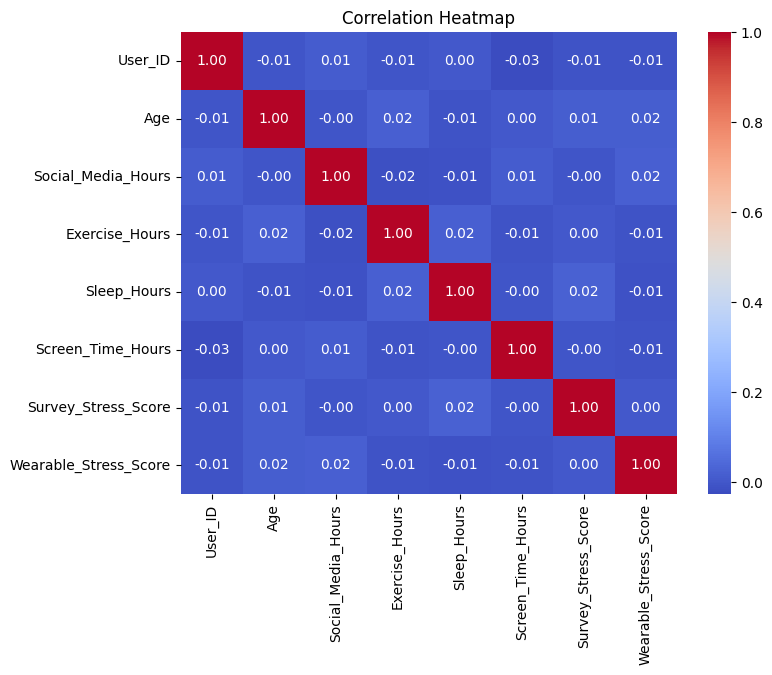

In [ ]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

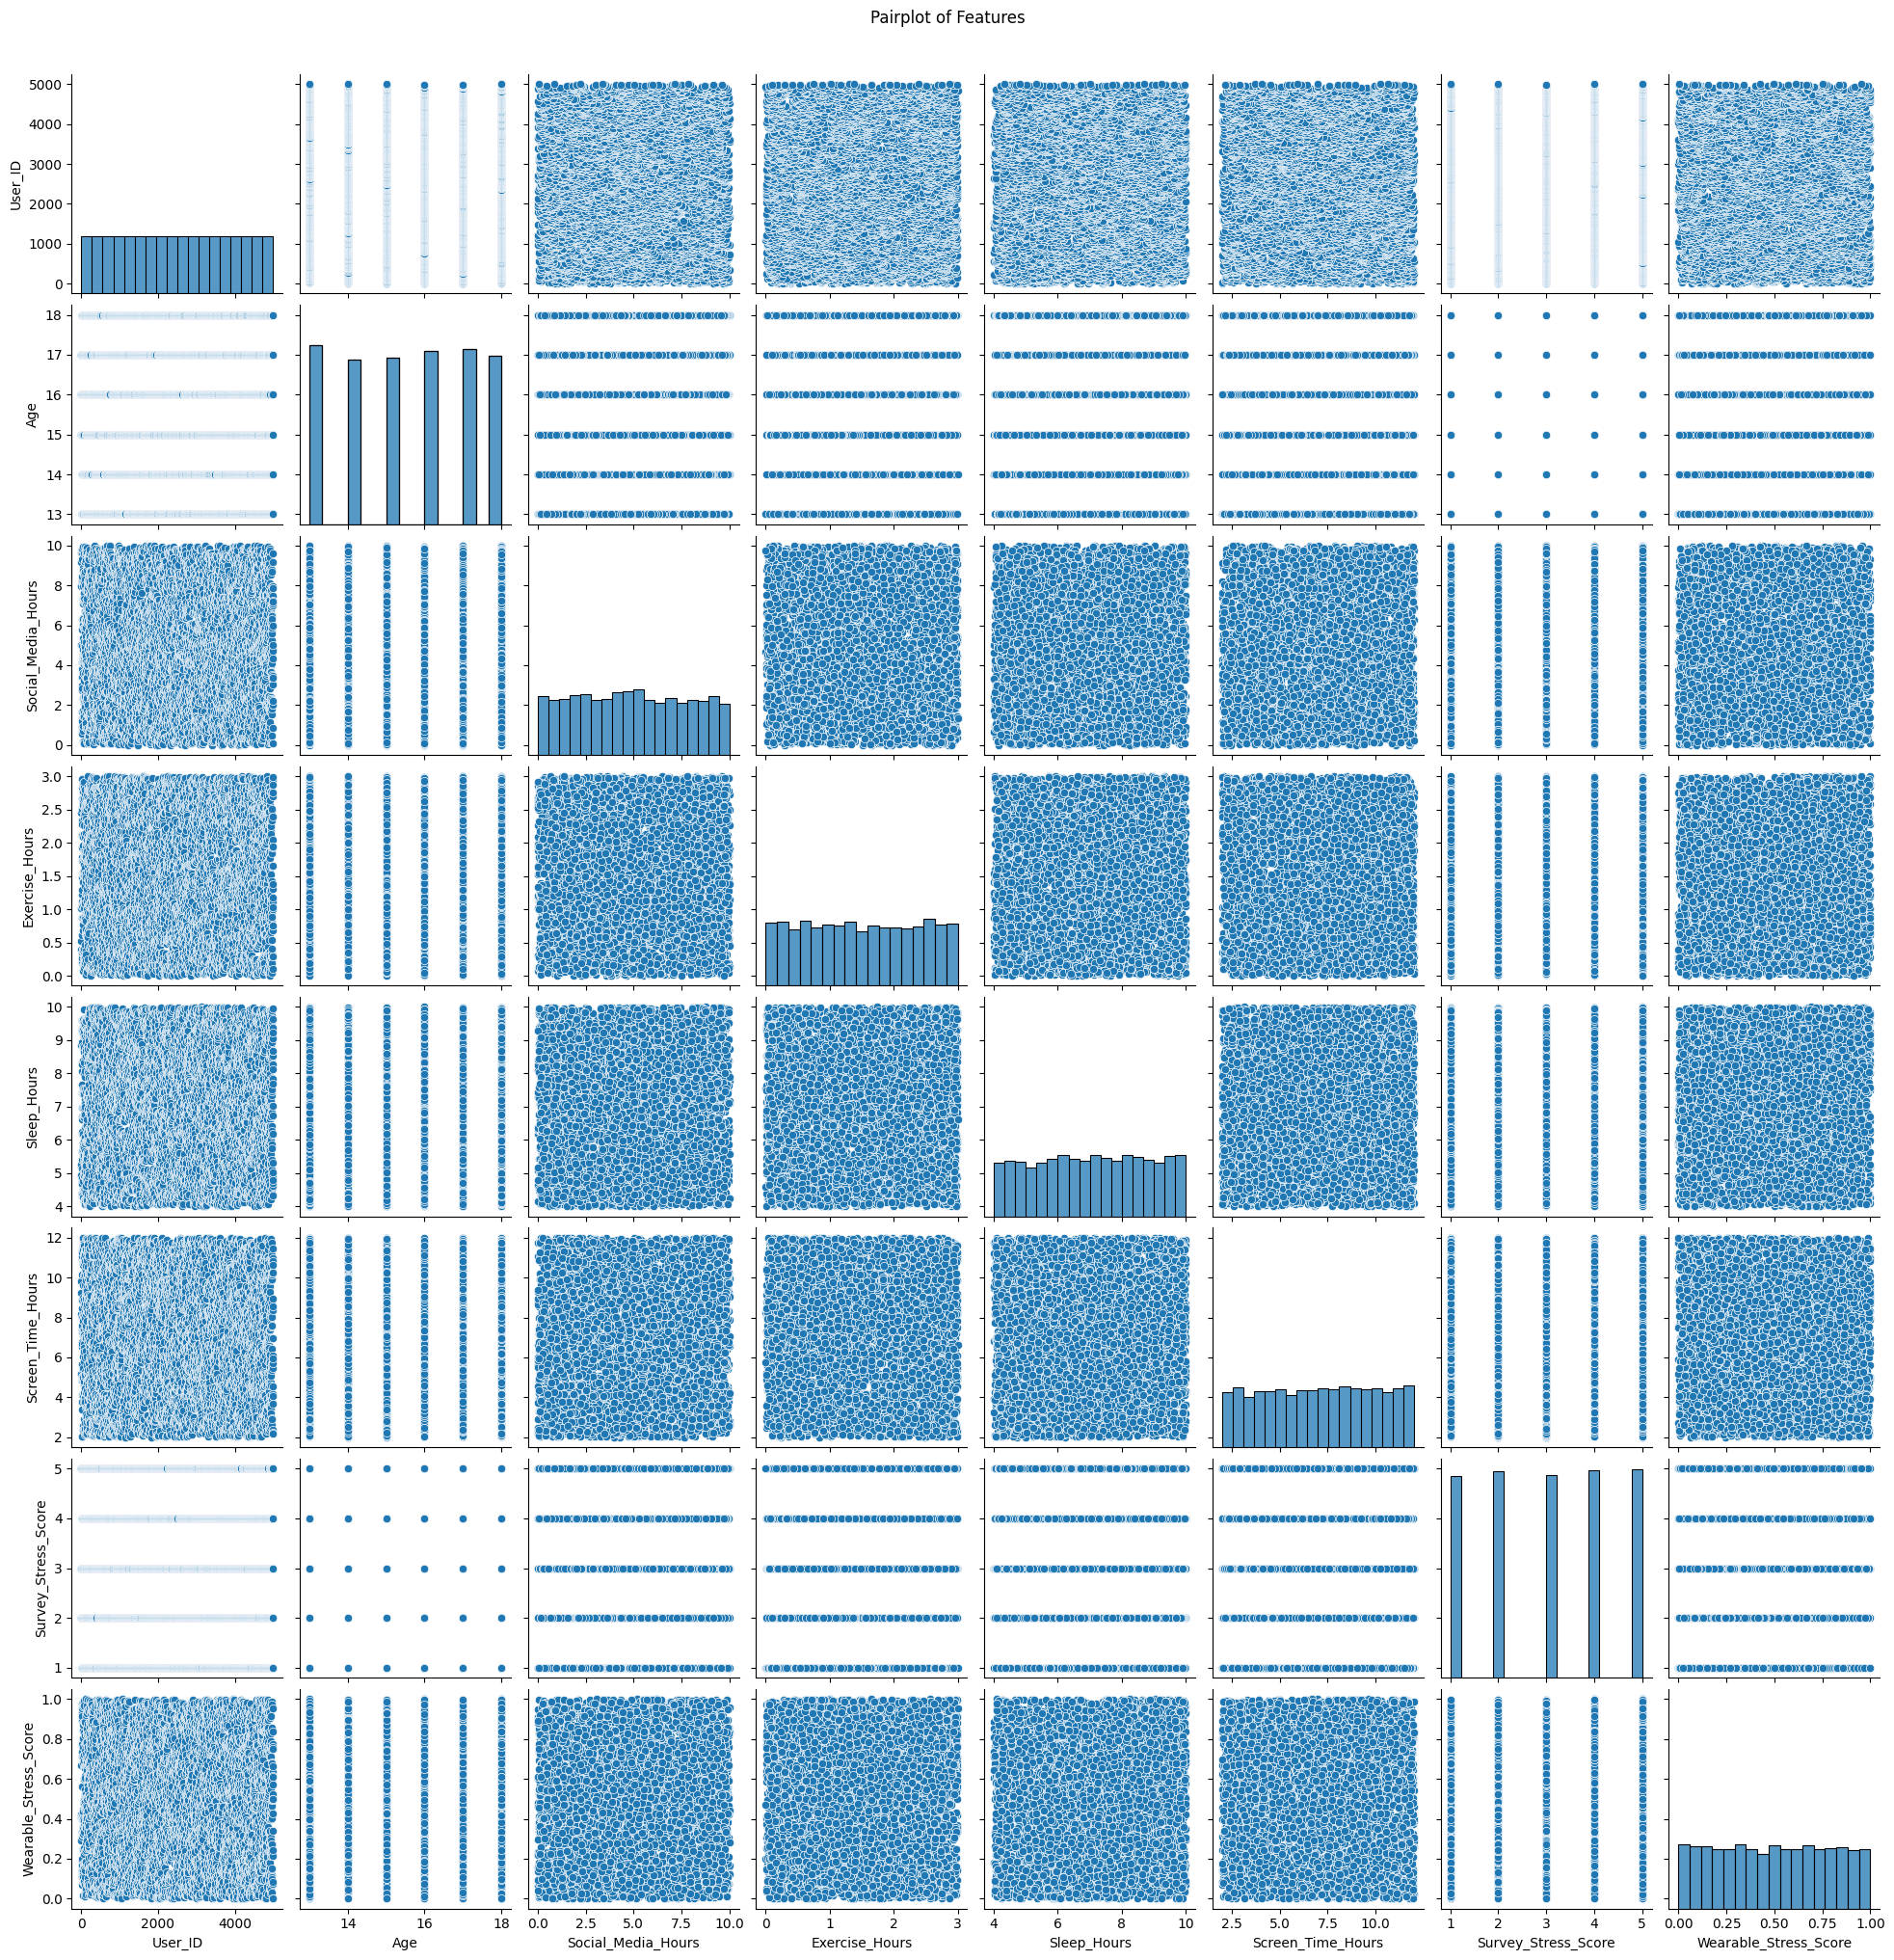

In [ ]:

# 2. Pairplot (Scatterplot matrix)
sns.pairplot(numeric_df, diag_kind='hist', height=2.5)
plt.suptitle("Pairplot of Features", y=1.02)
plt.show()


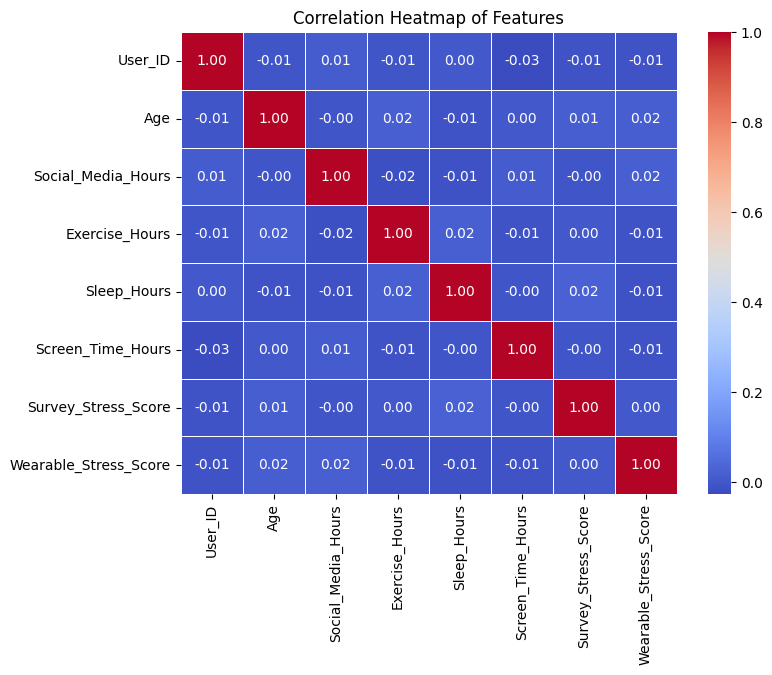

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)  # Select numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()


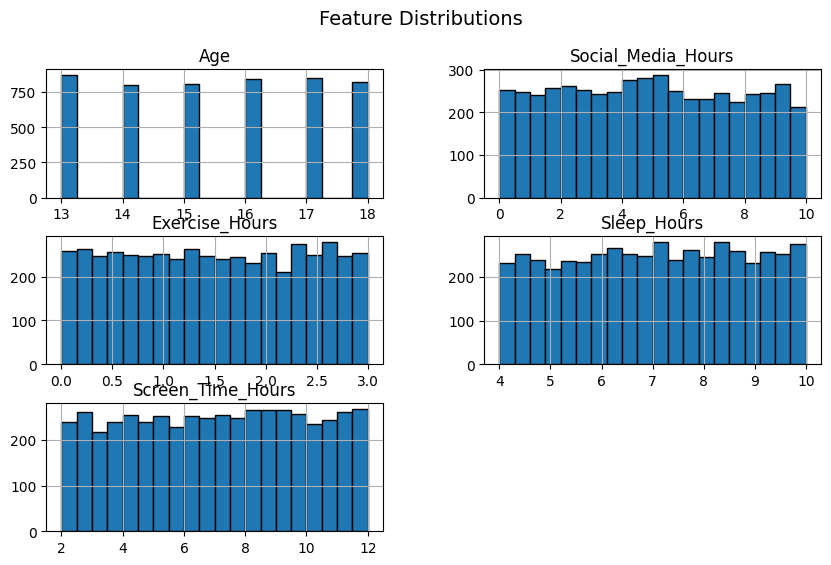

In [ ]:
# Plot histograms for feature distributions
df[features].hist(figsize=(10, 6), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()


#🧮 Step 4: Implementing Linear Regression
Now, we'll train a Linear Regression model.


In [ ]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr:.4f}")
print(f"Linear Regression R² Score: {r2_lr:.4f}")


Linear Regression MSE: 0.0853
Linear Regression R² Score: -0.0039


#📈 Step 5: Implementing Gradient Descent for Linear Regression
We will now manually implement linear regression using gradient descent.

In [ ]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):
        self.m, self.n = X.shape
        self.theta = np.zeros(self.n)  # Initialize weights
        self.bias = 0  # Initialize bias
        self.loss_history = []

        for i in range(self.iterations):
            y_pred = np.dot(X, self.theta) + self.bias
            error = y_pred - y

            # Compute gradients
            d_theta = (1 / self.m) * np.dot(X.T, error)
            d_bias = np.mean(error)

            # Update parameters
            self.theta -= self.learning_rate * d_theta
            self.bias -= self.learning_rate * d_bias

            # Compute loss
            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

            if i % 100 == 0:
                print(f"Iteration {i}: Loss {loss:.4f}")

    def predict(self, X):
        return np.dot(X, self.theta) + self.bias

# Train the Gradient Descent model
gd_model = LinearRegressionGD(learning_rate=0.01, iterations=1000)
gd_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_gd = gd_model.predict(X_test_scaled)

# Evaluate the model
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Gradient Descent MSE: {mse_gd:.4f}")
print(f"Gradient Descent R² Score: {r2_gd:.4f}")



Iteration 0: Loss 0.3279
Iteration 100: Loss 0.1162
Iteration 200: Loss 0.0879
Iteration 300: Loss 0.0841
Iteration 400: Loss 0.0836
Iteration 500: Loss 0.0835
Iteration 600: Loss 0.0835
Iteration 700: Loss 0.0835
Iteration 800: Loss 0.0835
Iteration 900: Loss 0.0835
Gradient Descent MSE: 0.0853
Gradient Descent R² Score: -0.0039


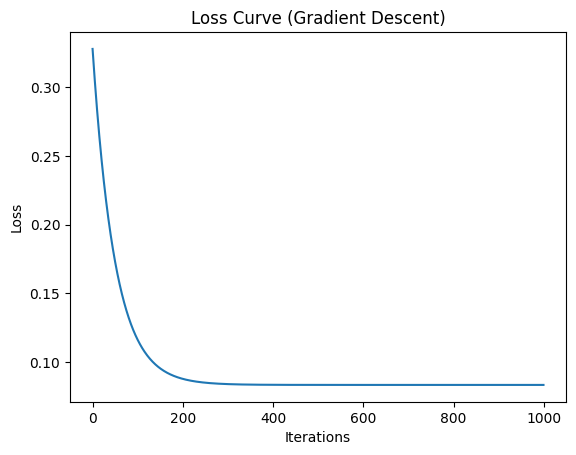

In [ ]:

# Plot loss curve
plt.plot(gd_model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve (Gradient Descent)")
plt.show()

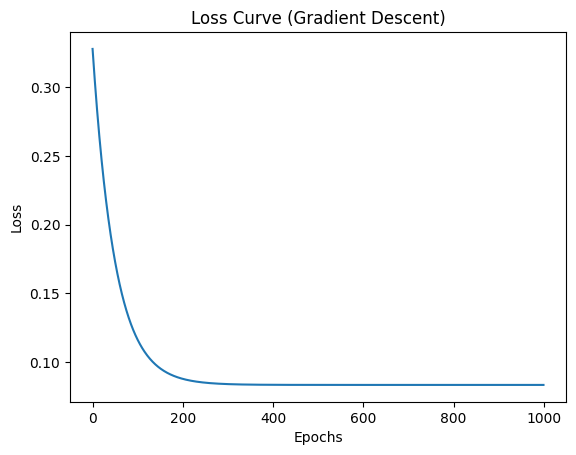

In [ ]:

# Plot loss curve
plt.plot(gd_model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve (Gradient Descent)")
plt.show()

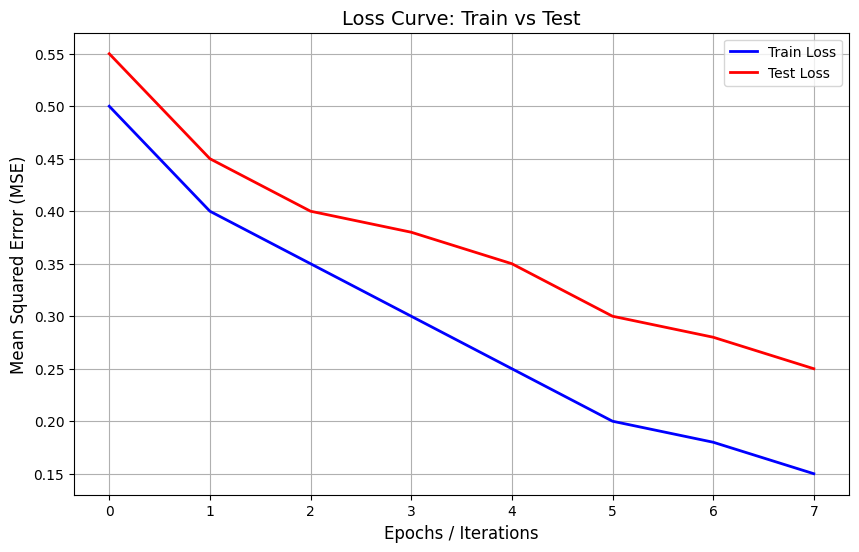

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, test_losses):
    """
    Plots the loss curves for training and test data.

    Args:
    train_losses (list or array): List of loss values for the training data over epochs/iterations.
    test_losses (list or array): List of loss values for the test data over epochs/iterations.
    """
    plt.figure(figsize=(10, 6))

    # Plot the loss curves for both train and test data
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    plt.plot(test_losses, label='Test Loss', color='red', linewidth=2)

    # Adding labels and title
    plt.xlabel('Epochs / Iterations', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.title('Loss Curve: Train vs Test', fontsize=14)

    # Add a legend
    plt.legend()

    # Adding grid for better visualization
    plt.grid(True)

    # Display the plot
    plt.show()

# Example usage:
# Assuming you have two lists: train_losses and test_losses
train_losses = [0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.18, 0.15]  # Replace with actual data
test_losses = [0.55, 0.45, 0.4, 0.38, 0.35, 0.3, 0.28, 0.25]  # Replace with actual data

plot_loss_curve(train_losses, test_losses)


Iteration 0: Train Loss 0.3279, Test Loss 0.3362
Iteration 100: Train Loss 0.1162, Test Loss 0.1213
Iteration 200: Train Loss 0.0879, Test Loss 0.0910
Iteration 300: Train Loss 0.0841, Test Loss 0.0864
Iteration 400: Train Loss 0.0836, Test Loss 0.0856
Iteration 500: Train Loss 0.0835, Test Loss 0.0854
Iteration 600: Train Loss 0.0835, Test Loss 0.0854
Iteration 700: Train Loss 0.0835, Test Loss 0.0854
Iteration 800: Train Loss 0.0835, Test Loss 0.0854
Iteration 900: Train Loss 0.0835, Test Loss 0.0854
Gradient Descent MSE: 0.0853
Gradient Descent R² Score: -0.0039


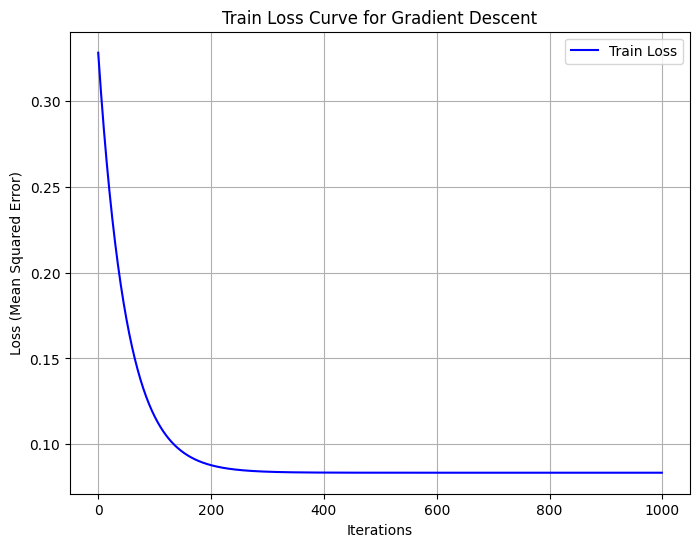

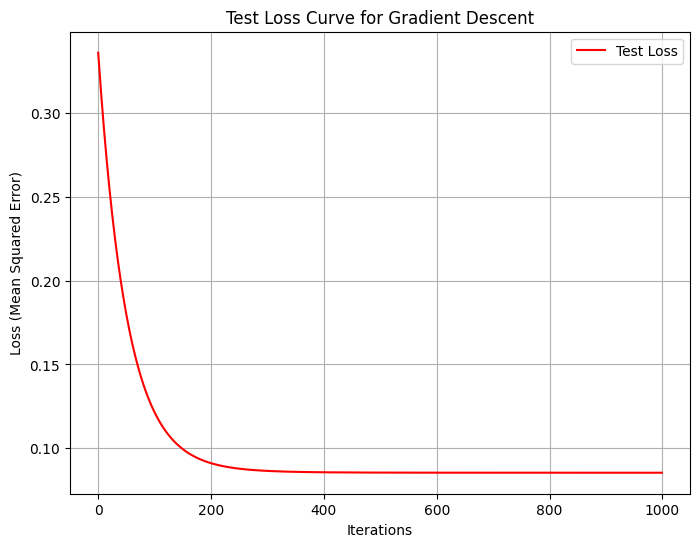

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X_train, y_train, X_test, y_test):
        self.m, self.n = X_train.shape
        self.theta = np.zeros(self.n)  # Initialize weights
        self.bias = 0  # Initialize bias
        self.train_loss_history = []
        self.test_loss_history = []

        for i in range(self.iterations):
            # Training predictions
            y_train_pred = np.dot(X_train, self.theta) + self.bias
            error_train = y_train_pred - y_train

            # Compute gradients
            d_theta = (1 / self.m) * np.dot(X_train.T, error_train)
            d_bias = np.mean(error_train)

            # Update parameters
            self.theta -= self.learning_rate * d_theta
            self.bias -= self.learning_rate * d_bias

            # Compute train loss (MSE)
            train_loss = np.mean(error_train ** 2)
            self.train_loss_history.append(train_loss)

            # Compute test loss (MSE)
            y_test_pred = np.dot(X_test, self.theta) + self.bias
            error_test = y_test_pred - y_test
            test_loss = np.mean(error_test ** 2)
            self.test_loss_history.append(test_loss)

            # Print every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: Train Loss {train_loss:.4f}, Test Loss {test_loss:.4f}")

    def predict(self, X):
        return np.dot(X, self.theta) + self.bias

    def plot_loss_curves_separated(self):
        # Plot Train Loss
        plt.figure(figsize=(8, 6))
        plt.plot(self.train_loss_history, label='Train Loss', color='blue')
        plt.xlabel('Iterations')
        plt.ylabel('Loss (Mean Squared Error)')
        plt.title('Train Loss Curve for Gradient Descent')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Plot Test Loss
        plt.figure(figsize=(8, 6))
        plt.plot(self.test_loss_history, label='Test Loss', color='red')
        plt.xlabel('Iterations')
        plt.ylabel('Loss (Mean Squared Error)')
        plt.title('Test Loss Curve for Gradient Descent')
        plt.legend()
        plt.grid(True)
        plt.show()

# Train the Gradient Descent model
gd_model = LinearRegressionGD(learning_rate=0.01, iterations=1000)
gd_model.fit(X_train_scaled, y_train, X_test_scaled, y_test)

# Predictions
y_pred_gd = gd_model.predict(X_test_scaled)

# Evaluate the model
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Gradient Descent MSE: {mse_gd:.4f}")
print(f"Gradient Descent R² Score: {r2_gd:.4f}")

# Plot the loss curves separately for train and test
gd_model.plot_loss_curves_separated()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and preprocess data
X = df[['Age', 'Social_Media_Hours']]
y = df['Wearable_Stress_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Loss (MSE)
from sklearn.metrics import mean_squared_error
train_loss = mean_squared_error(y_train, lr_model.predict(X_train))
test_loss = mean_squared_error(y_test, lr_model.predict(X_test))

print(f"Train Loss: {train_loss}")
print(f"Test Loss: {test_loss}")


Train Loss: 0.08368347129668881
Test Loss: 0.08477574999482906


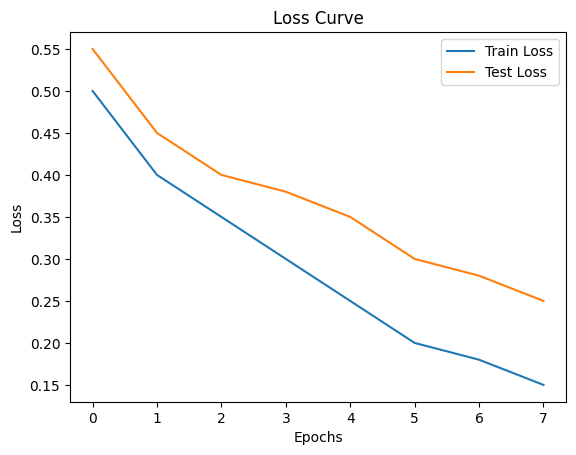

In [ ]:
import matplotlib.pyplot as plt

# Example placeholder
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()


#🌲 Step 6: Implementing Decision Trees & Random Forest
We compare Decision Tree Regression and Random Forest Regression.

In [ ]:
# Train Decision Tree Model
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate Decision Tree
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Decision Tree R² Score: {r2_dt:.4f}")

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf:.4f}")
print(f"Random Forest R² Score: {r2_rf:.4f}")


Decision Tree MSE: 0.1667
Decision Tree R² Score: -0.9633
Random Forest MSE: 0.0874
Random Forest R² Score: -0.0298


#🏆 Step 7: Saving the Best Model
We'll save the model with the lowest loss.

In [ ]:
# Choose the best model
best_model = min([(lr_model, mse_lr), (gd_model, mse_gd), (dt_model, mse_dt), (rf_model, mse_rf)], key=lambda x: x[1])[0]

# Save the best model
joblib.dump(best_model, "/mnt/data/best_model.pkl")
print("Best model saved successfully!")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/best_model.pkl'

#🎯 Step 8: Using the Best Model for Predictions
Now, let's load the best model and make a new prediction.

In [ ]:
# Load best model
loaded_model = joblib.load("/mnt/data/best_model.pkl")

# Example input (Modify this with real data)
example_input = np.array([[2, 3, 7, 4, 25]])  # Example: 2 hrs social media, 3 hrs exercise, etc.
example_input_scaled = scaler.transform(example_input)

# Make prediction
prediction = loaded_model.predict(example_input_scaled)
print(f"Predicted Stress Score: {prediction[0]:.2f}")
